In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("white")

In [4]:
df = pd.read_csv("german_credit_data_100k.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,35,male,2,own,NaN,NaN,3843,30,radio/TV,good
1,1,51,female,2,own,NaN,little,2911,11,education,good
2,2,49,female,1,rent,little,little,7658,31,radio/TV,bad
3,3,47,male,1,rent,NaN,NaN,1765,17,education,good
4,4,27,male,2,own,little,moderate,3608,40,vacation/others,bad


In [5]:
df['Age'].describe()

count    100000.000000
mean         35.916520
std          10.673303
min          19.000000
25%          28.000000
50%          36.000000
75%          43.000000
max          75.000000
Name: Age, dtype: float64

In [6]:
# Output: Risk = good (low risk)
#         Risk = bad (High risk)

In [7]:
df['Risk'].value_counts()

Risk
good    70109
bad     29891
Name: count, dtype: int64

In [8]:
df.shape

(100000, 11)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Unnamed: 0        100000 non-null  int64
 1   Age               100000 non-null  int64
 2   Sex               100000 non-null  str  
 3   Job               100000 non-null  int64
 4   Housing           100000 non-null  str  
 5   Saving accounts   81747 non-null   str  
 6   Checking account  60659 non-null   str  
 7   Credit amount     100000 non-null  int64
 8   Duration          100000 non-null  int64
 9   Purpose           100000 non-null  str  
 10  Risk              100000 non-null  str  
dtypes: int64(5), str(6)
memory usage: 8.4 MB


In [10]:
df.isna().sum()

Unnamed: 0              0
Age                     0
Sex                     0
Job                     0
Housing                 0
Saving accounts     18253
Checking account    39341
Credit amount           0
Duration                0
Purpose                 0
Risk                    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.dropna().reset_index(drop = True)

In [13]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,2,49,female,1,rent,little,little,7658,31,radio/TV,bad
1,4,27,male,2,own,little,moderate,3608,40,vacation/others,bad
2,8,26,male,2,free,little,little,250,34,radio/TV,bad
3,11,29,female,2,own,little,moderate,5684,42,furniture/equipment,bad
4,12,19,male,2,own,little,moderate,6619,22,furniture/equipment,bad
...,...,...,...,...,...,...,...,...,...,...,...
50479,99988,43,female,1,rent,little,moderate,2293,32,radio/TV,good
50480,99989,43,male,2,own,little,moderate,6582,36,car,bad
50481,99992,47,male,2,own,little,little,9865,66,car,bad
50482,99996,36,female,1,rent,quite rich,moderate,250,5,car,good


In [14]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [15]:
df.drop(columns='Unnamed: 0', inplace = True)

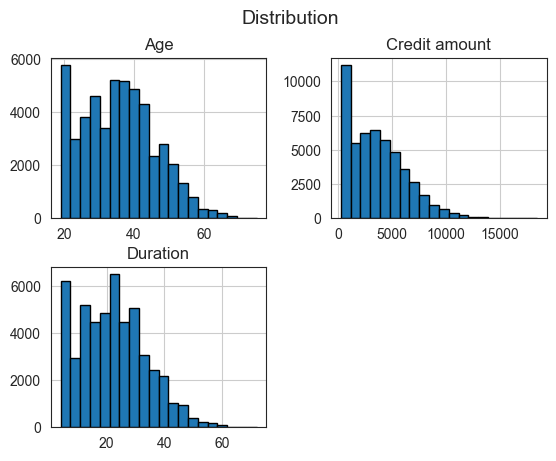

In [16]:
df[['Age','Credit amount','Duration']].hist(bins=20, edgecolor = 'black')
plt.suptitle("Distribution", fontsize = 14)
plt.show()

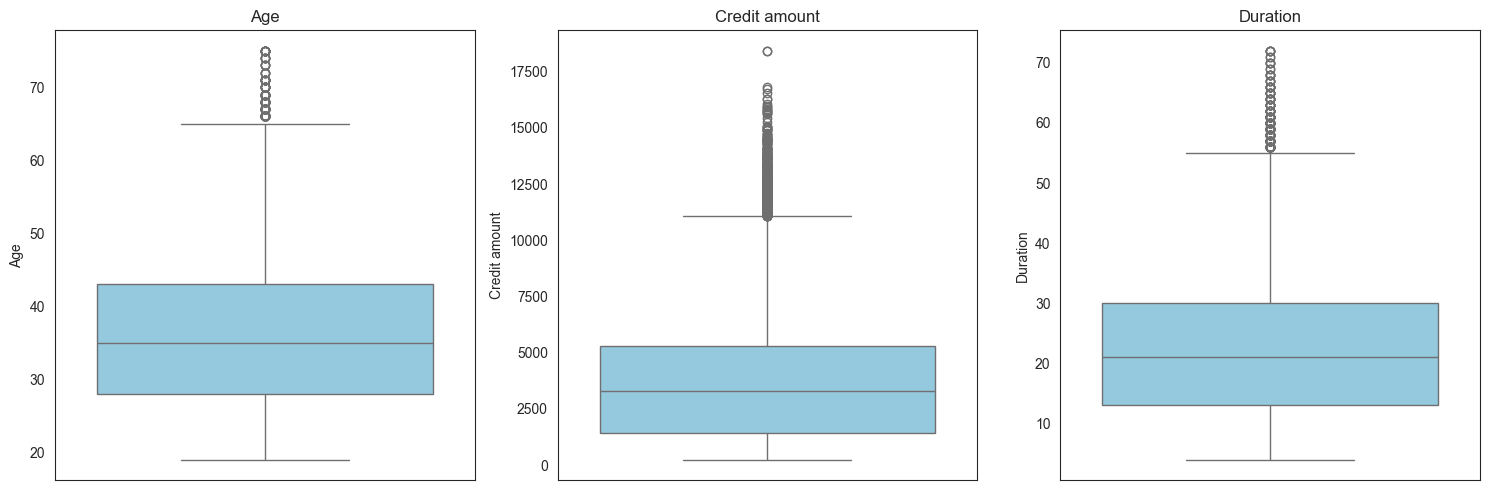

In [17]:
plt.figure(figsize=(15,5))
for i, col in enumerate(['Age','Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color ='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
532,44,female,3,own,little,little,6209,64,car,bad
1071,21,female,2,own,little,little,10837,62,radio/TV,bad
1783,41,female,1,rent,little,little,5820,60,car,bad
2022,25,male,2,rent,little,little,7317,62,car,bad
2077,19,male,1,own,little,little,3403,61,car,bad
...,...,...,...,...,...,...,...,...,...,...
48099,53,male,2,rent,little,little,10225,63,furniture/equipment,bad
48438,40,male,3,own,little,little,12631,61,car,bad
49403,43,male,3,own,little,little,12543,60,furniture/equipment,bad
50020,19,female,2,rent,little,little,5841,62,furniture/equipment,bad


In [19]:
categorical_cols = ['Sex','Job','Housing','Saving accounts', 'Checking account','Purpose' ]

C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', ord

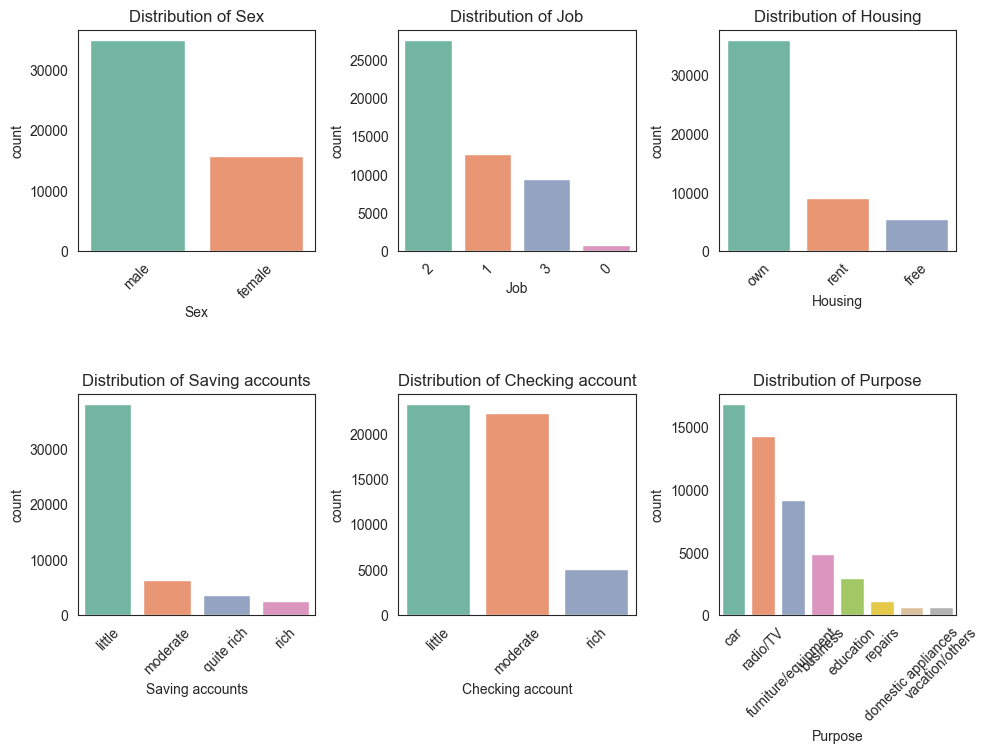

In [20]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
corr = df[['Age','Job', 'Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.050849,0.050494,-0.022503
Job,0.050849,1.000000,0.263024,0.186084
Credit amount,0.050494,0.263024,1.000000,0.600832
Duration,-0.022503,0.186084,0.600832,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

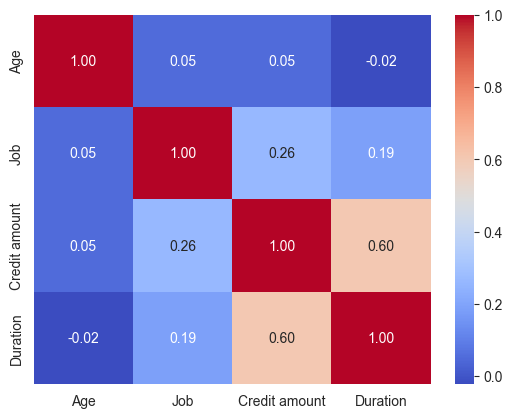

In [22]:
sns.heatmap(corr, annot = True, cmap ='coolwarm', fmt ='.2f')
plt.show

In [23]:
df.groupby('Job')['Credit amount'].mean()


Job
0    1931.669211
1    2747.743620
2    3636.075620
3    4807.236895
Name: Credit amount, dtype: float64

In [24]:
df.groupby("Sex")['Credit amount'].mean()

Sex
female    3613.108348
male      3601.651091
Name: Credit amount, dtype: float64

In [25]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,3712.241818,3675.751947,4065.802632,3640.222561,3619.727184,3662.084801,3513.508621,3750.475410
own,3564.691705,3595.568590,3345.141892,3550.792571,3649.238365,3602.859609,3708.119438,3658.313466
rent,3645.013289,3508.333778,3729.704762,3575.773408,3645.105101,3633.739900,3408.736842,2874.190000


Text(0.5, 1.0, 'Credit amount vs Age colored by Sex and sized by Duration')

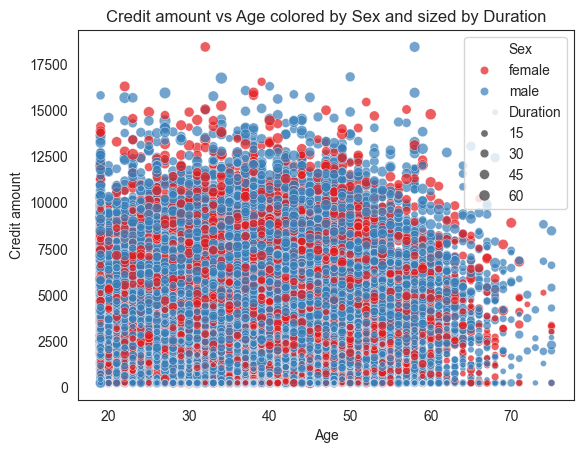

In [26]:
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Sex', size='Duration', alpha=0.7, palette='Set1')
plt.title('Credit amount vs Age colored by Sex and sized by Duration')

C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\2035416251.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette = 'Pastel1')


Text(0.5, 1.0, 'Credit amount Distribution by Saving')

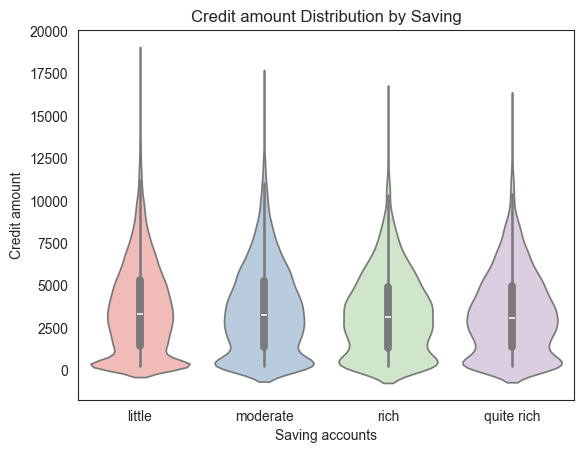

In [27]:
sns.violinplot(data=df, x='Saving accounts', y='Credit amount', palette = 'Pastel1')
plt.title('Credit amount Distribution by Saving')

In [28]:
df['Risk'].value_counts(normalize=True) * 100

Risk
good    55.215514
bad     44.784486
Name: proportion, dtype: float64

C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4062735173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4062735173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\4062735173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')


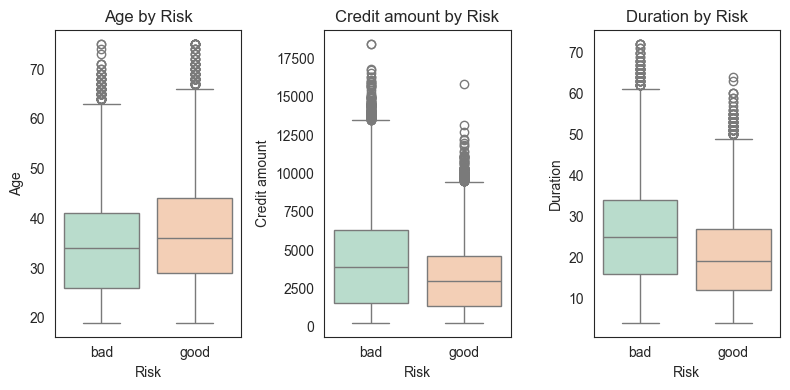

In [29]:
plt.figure(figsize=(8,4))
for i, col in enumerate(['Age','Credit amount', 'Duration']):
    plt.subplot(1,3, i+1)
    sns.boxplot(data=df, x='Risk', y=col, palette='Pastel2')
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [30]:
df.groupby("Risk")[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.338361,4186.689858,25.124287
good,36.579229,3133.564843,19.571587


In [31]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

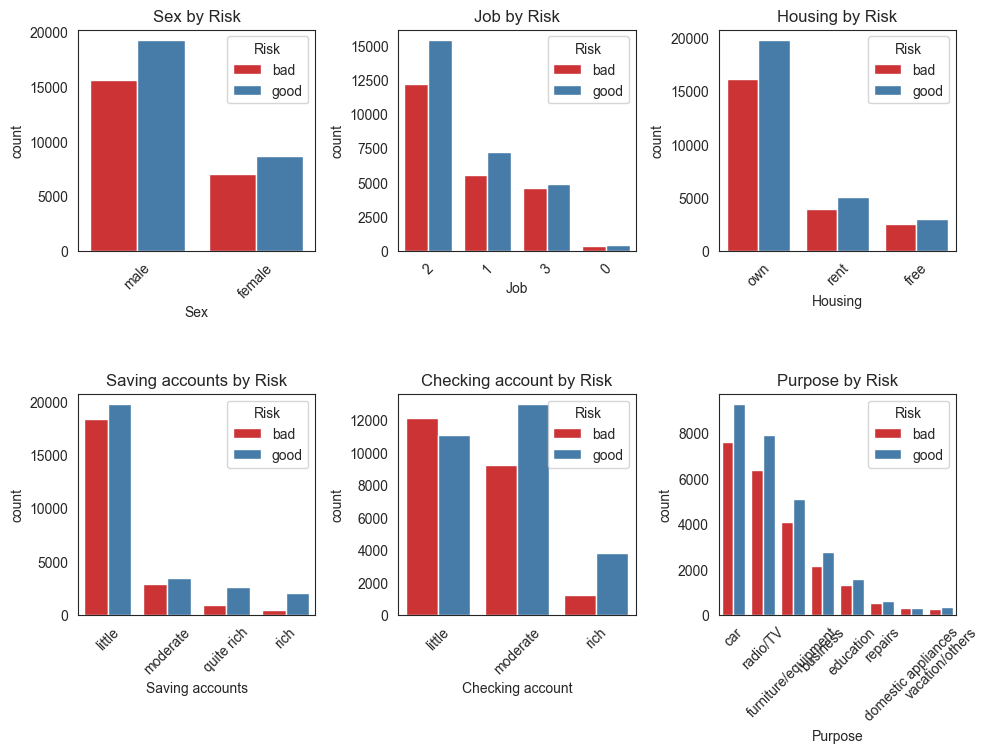

In [32]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data=df, x=col, hue='Risk', palette='Set1',order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [34]:
features = ['Age', 'Sex','Job','Housing','Saving accounts','Checking account','Duration']

In [35]:
target = 'Risk'

In [36]:
df_model = df[features + [target]].copy()

In [37]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Duration,Risk
0,49,female,1,rent,little,little,31,bad
1,27,male,2,own,little,moderate,40,bad
2,26,male,2,free,little,little,34,bad
3,29,female,2,own,little,moderate,42,bad
4,19,male,2,own,little,moderate,22,bad


In [38]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [39]:
cat_cols = df_model.select_dtypes(include='object').columns.drop('Risk')

C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_15600\3992402669.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.drop('Risk')


In [40]:
le_dict = {}

In [41]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='str')

In [42]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le_dict
    joblib.dump(le, f"{col}_encoder.pkl")


In [43]:
le_target = LabelEncoder()

In [44]:
df_model[target] = le_target.fit_transform(df_model[target])

In [45]:
df_model[target].value_counts()

Risk
1    27875
0    22609
Name: count, dtype: int64

In [46]:
joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [47]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Duration,Risk
0,49,0,1,2,0,0,31,0
1,27,1,2,1,0,1,40,0
2,26,1,2,0,0,0,34,0
3,29,0,2,1,0,1,42,0
4,19,1,2,1,0,1,22,0


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X = df_model.drop(target, axis=1)
y = df_model[target]

In [50]:
X_train, X_text, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 1)

In [51]:
X_train.shape

(40387, 7)

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [53]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs = -1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [55]:
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dt_param_grid = {
    "max_depth" : [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [56]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_text, y_test )


In [57]:
print('Decision Tree Accuracy', acc_dt)

Decision Tree Accuracy 0.642567099138358


In [58]:
print('Best Parameters', params_dt)

Best Parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [59]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

In [62]:
rf_params_grid = {
    'n_estimators':[100,200],
    'max_depth': [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [63]:
best_rf, acc_rf, params_rf = train_model(rf, rf_params_grid, X_train, y_train, X_text, y_test )


In [64]:
print('Random Forest Accuracy', acc_rf)

Random Forest Accuracy 0.642567099138358


In [65]:
et = ExtraTreesClassifier(random_state = 1, class_weight='balanced', n_jobs=-1)

In [66]:
et_params_grid = {
    'n_estimators':[100,200],
    'max_depth': [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [67]:
best_et, acc_et, params_et = train_model(et, et_params_grid, X_train, y_train, X_text, y_test )


In [69]:
print('Extra Tree Accuracy', acc_et)

Extra Tree Accuracy 0.6404872734475587


In [70]:
xgb = XGBClassifier(random_state=1, scale_pos_weight = (y_train==0).sum()/(y_train==1).sum(), use_label_encoder=False, eval_metric="logloss")

In [72]:
xgb_params_grid = {
    'n_estimators':[100,200],
    'max_depth': [5,7,10, None],
    "learning_rate": [0.01,0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

In [73]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_params_grid, X_train, y_train, X_text, y_test )


d:\GenAI\Barclays\smart-Credit-Risk-Demand-Forecasting-Platform\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:06:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [74]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.646231553926909


In [75]:
best_et.predict(X_text)

array([0, 1, 0, ..., 1, 0, 1], shape=(10097,))

In [77]:
joblib.dump(best_et, "model_extra_tree.pkl")

['model_extra_tree.pkl']